# VGG11 - Individual Baseline Run


In [1]:
import sys
import os

import torch

sys.path.append(os.path.abspath("../src"))

from models import VGG11
from data import prepare_full_dataframe, prepare_data, sample_image_path, get_transforms
from train import run_training_pipeline, run_smoke_test
from train_eval import evaluate, predict_single_image
from utils import (
    get_device,
    get_model_path,
    plot_training_history_compact,
    plot_confusion_matrix_figure,
)
import config

print(f"Python:         {sys.executable}")
print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:            {torch.cuda.get_device_name(0)}")

Python:         c:\Users\profb\PROJECTS\cxr-model-benchmark\.venv\Scripts\python.exe
PyTorch:        2.11.0+cu128
CUDA available: True
GPU:            NVIDIA GeForce RTX 5090 Laptop GPU


In [2]:
dataset_path = config.DATASET_PATH
print("Dataset location:", dataset_path)

metadata_file = os.path.join(dataset_path, "Data_Entry_2017.csv")
df = prepare_full_dataframe(metadata_file, dataset_path)

print(f"Total images:    {len(df)}")
print(f"Unique patients: {df['Patient ID'].nunique()}")

Dataset location: C:\Users\profb\PROJECTS\datasets\NIH_Chest_X-Rays
Total images:    112120
Unique patients: 30805


In [3]:
print(df["split"].value_counts())

split
train    78934
val      16874
test     16312
Name: count, dtype: int64


In [4]:
train_loader, val_loader, test_loader = prepare_data(df)
device = get_device()

Using CUDA (GPU)


## Smoke Test


In [5]:
run_smoke_test(
    model_name="VGG11",
    model_builder=lambda: VGG11(num_classes=2, in_channels=1),
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
)


=== Smoke test: VGG11 (epochs=1, patience=1, batches=1) ===

=== Training VGG11 ===

=== Run Configuration ===
Model: VGG11
Training: epochs=1, patience=3, batch_size=256, image_size=256, seed=42
Precision/Memory: amp_enabled=True, amp_dtype=bf16, channels_last(global=True, override=None, effective=True)
Optimization: layerwise_lr_enabled=True, uses_param_groups=True, freeze_backbone_enabled=True, freeze_backbone_epochs=1, lr=0.0001, backbone_lr=3e-05, head_lr=0.0002, weight_decay=5e-05, label_smoothing=0.03
Scheduler: enabled=True, type=warmup_cosine, start_epoch=1, warmup_epochs=0, warmup_start_factor=0.4, cosine_t_max=6, min_lr=1e-06, steps_per_epoch=1
Checkpoint Resume: False
Model Overrides: {'patience': 3, 'backbone_lr': 3e-05, 'head_lr': 0.0002, 'freeze_backbone_epochs': 1, 'scheduler_cosine_t_max': 6}
Starting fresh training (resume disabled): c:\Users\profb\PROJECTS\cxr-model-benchmark\outputs\checkpoints\best_vgg11\latest.pt
AMP enabled (bf16, grad scaler: off)
channels_last

Train Epoch 1:   0%|          | 0/1 [00:00<?, ?it/s]

  VRAM a/r/p: 1.90G(7.9%)/6.67G(27.9%)/6.64G(27.8%)


Val Epoch 1:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/1 | ETA (Remaining): 00:00:00 | Total ETA: 00:00:04
  Train Loss: 0.7455 | Train Acc: 0.4492
  Val Loss: 1.4122 | Val Acc: 0.4648
  Val Precision: 0.4648
  Val Recall: 1.0000 | Val F1: 0.6347
  Val AUPRC: 0.5190
  Backbone LR: 2.80574e-05 | Head LR: 0.00018667
  Optimizer: AdamW | Weight Decay: 5e-05 | No-Decay Groups: 2
------------------------------------------------------------
Saved best model to c:\Users\profb\PROJECTS\cxr-model-benchmark\outputs\models\best_vgg11.pt
------------------------------------------------------------


Test:   0%|          | 0/1 [00:00<?, ?it/s]

({'model': 'VGG11',
  'epochs': 1,
  'batch_size': 256,
  'image_size': 256,
  'test_loss': 1.3161067962646484,
  'accuracy': 0.51953125,
  'precision': 0.51953125,
  'recall': 1.0,
  'f1': 0.6838046272493573,
  'auprc': 0.6407391584956299},
 {'train_loss': [0.7454909682273865],
  'train_acc': [0.44921875],
  'val_loss': [1.4122053384780884],
  'val_acc': [0.46484375],
  'val_precision': [0.46484375],
  'val_recall': [1.0],
  'val_f1': [0.6346666666666667],
  'val_auprc': [0.5189769476057431],
  'lr': [0.00018666952767655166],
  'lr_backbone': [2.8057368354874363e-05],
  'lr_head': [0.00018666952767655166],
  'backbone_frozen': [True],
  'vram_peak_pct': [27.78526889622152],
  'best_epoch': 1})

## Training


In [6]:
seed = 42

torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

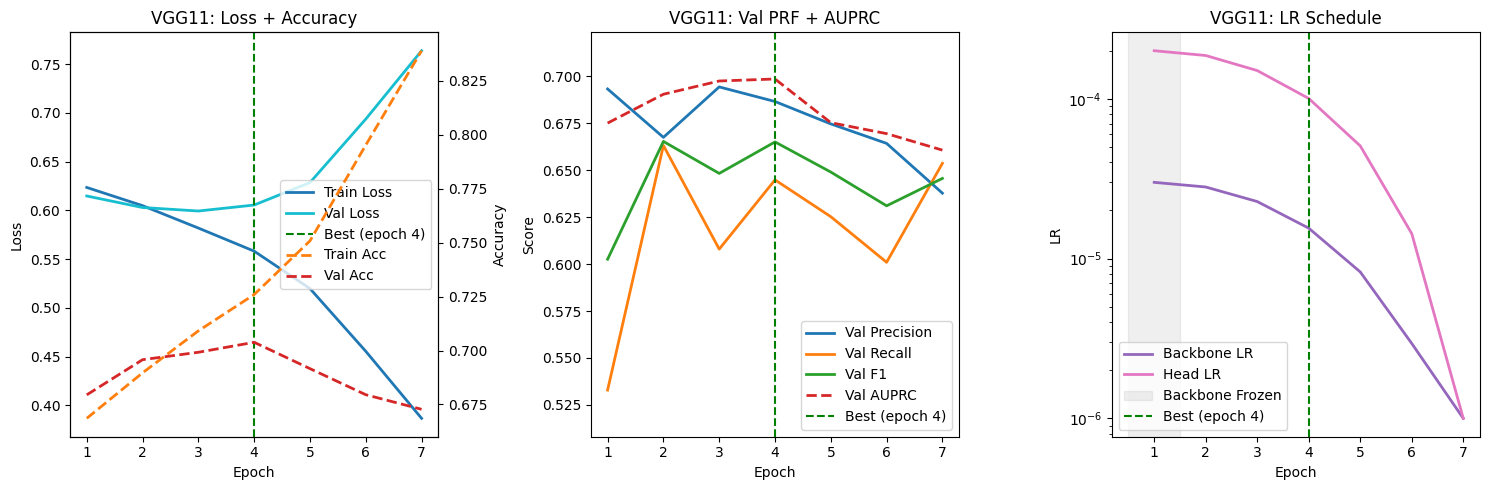

Early stopping at epoch 7 (patience 3 exceeded)


Test:   0%|          | 0/64 [00:19<?, ?it/s]

Single run complete: best_epoch=4, best_val_auprc=0.6986410367412215


In [ ]:
print(f"\n=== Run #1 | seed={seed} ===")
metrics, history = run_training_pipeline(
    model_name="VGG11",
    model_builder=lambda: VGG11(num_classes=2, in_channels=1),
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=True,
)

best_epoch = history.get("best_epoch")
best_val_auprc = None
if best_epoch is not None and "val_auprc" in history and history["val_auprc"]:
    best_val_auprc = float(history["val_auprc"][best_epoch - 1])

print(
    f"Run #1 complete: best_epoch={best_epoch}, "
    f"best_val_auprc={best_val_auprc if best_val_auprc is not None else 'N/A'}"
)

In [20]:
baseline_auprc = 0.686

print("\n=== Run Snapshot ===")
print(f"Best epoch: {best_epoch if best_epoch is not None else 'N/A'}")
if best_val_auprc is not None:
    print(f"Best val AUPRC (Delta baseline): {best_val_auprc:.4f} ({best_val_auprc - baseline_auprc:.4f})")
else:
    print("Best val AUPRC: N/A")

test_auprc = metrics.get("auprc")
if test_auprc is not None:
    print(f"Test AUPRC: {float(test_auprc):.4f}")
else:
    print("Test AUPRC: N/A")


=== Run Snapshot ===
Best epoch: 4
Best val AUPRC (Delta baseline): 0.6986 (0.0126)
Test AUPRC: 0.7017


### Val Metrics

In [13]:
print("\n=== Run Summary ===")
print(f"Model: {metrics.get('model', 'VGG11')}")
print(f"Epochs: {metrics.get('epochs', len(history.get('train_loss', [])))}")

for key in ["test_loss", "accuracy", "precision", "recall", "f1", "auprc"]:
    value = metrics.get(key)
    if value is None:
        print(f"{key}: N/A")
    else:
        print(f"{key}: {float(value):.4f}")


=== Run Summary ===
Model: VGG11
Epochs: 7
test_loss: 0.6016
accuracy: 0.7051
precision: 0.6887
recall: 0.6599
f1: 0.6740
auprc: 0.7017
